
Loaded results:
 concurrency  requests  failures  failure_rate     avg_ms  p50_ms  p95_ms  p99_ms  max_ms       rps
           1        78         0           0.0 221.614437     220     230     270     270  2.707483
           4       278         0           0.0 264.483078     270     290     340     340  9.605750
           8       529         0           0.0 286.807641     290     310     400     430 18.228156
          16       940         0           0.0 341.839432     340     380     480     490 32.396977
          32      1484         0           0.0 471.837841     470     540     660     670 51.221271


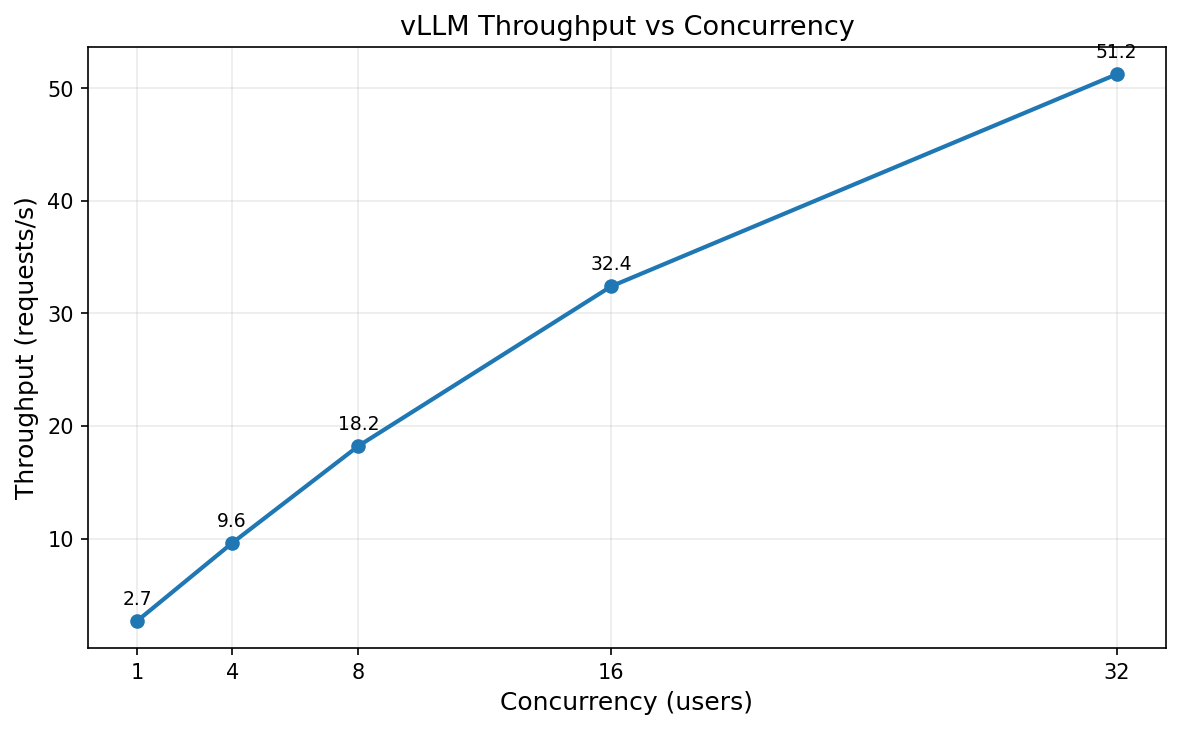

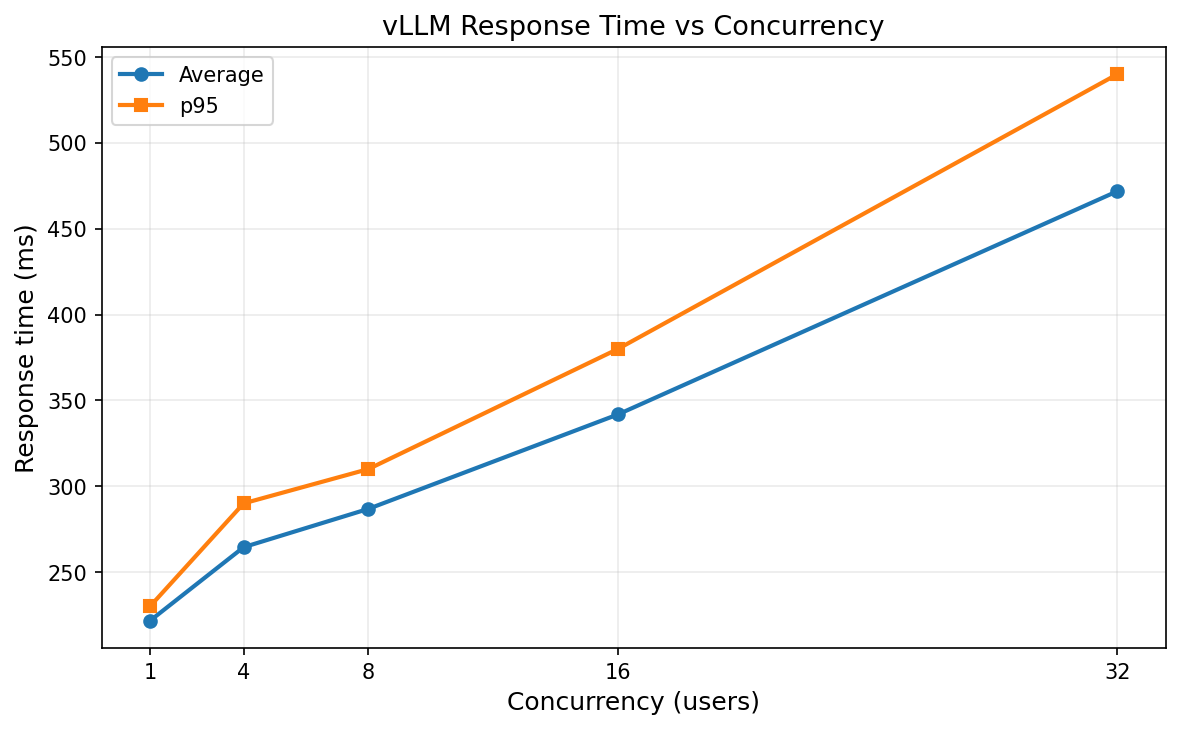

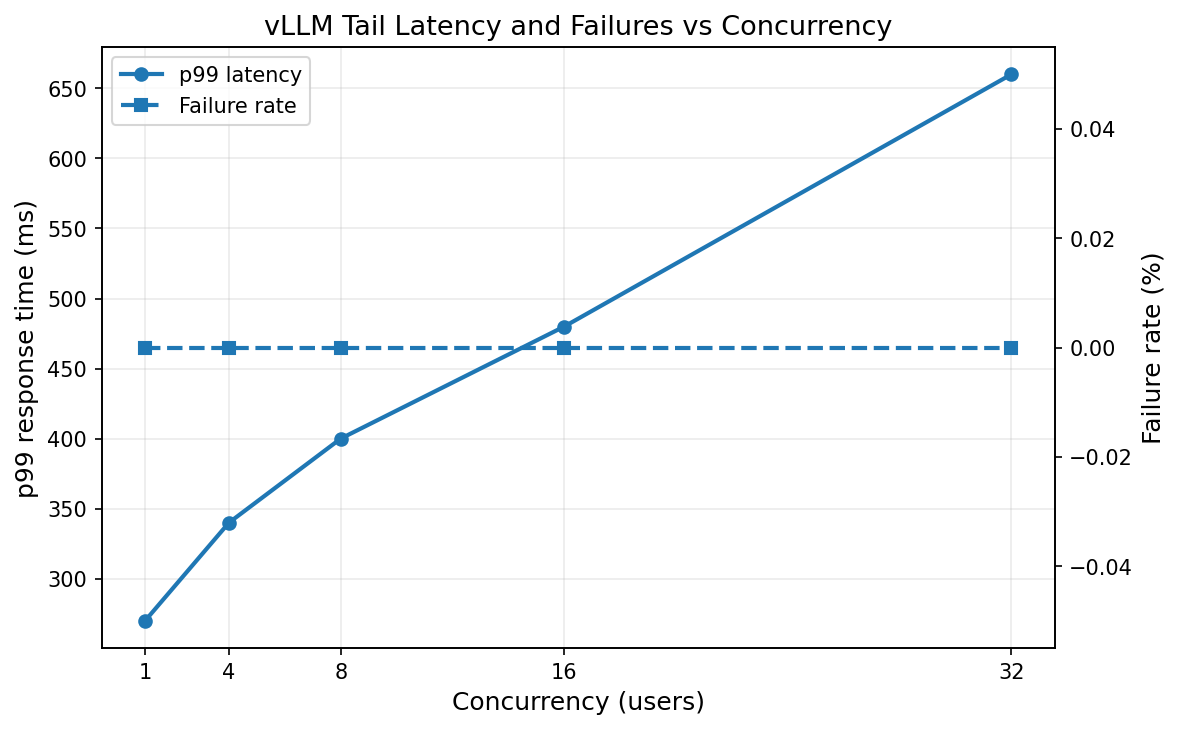


Graphs saved to:
/home/ismail/Documents/llm-lab/mini-inference-engine/experiments/vllm_load/results/graphs


In [8]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Configuration
# ============================================================

RESULTS_DIR = Path("./vllm_load/results")

CSV_FILES = {
    1: RESULTS_DIR / "ramp_1_stats.csv",
    4: RESULTS_DIR / "ramp_4_stats.csv",
    8: RESULTS_DIR / "ramp_8_stats.csv",
    16: RESULTS_DIR / "ramp_16_stats.csv",
    32: RESULTS_DIR / "ramp_32_stats.csv",
}

OUTPUT_DIR = RESULTS_DIR / "graphs"
OUTPUT_DIR.mkdir(exist_ok=True)


# ============================================================
# Load Locust statistics
# ============================================================

rows = []

for concurrency, path in CSV_FILES.items():

    if not path.exists():
        print(f"WARNING: missing {path}")
        continue

    df = pd.read_csv(path)

    # Locust CSV normally contains one row for the endpoint
    # and one "Aggregated" row.
    endpoint_rows = df[df["Name"] != "Aggregated"]

    if endpoint_rows.empty:
        # fallback: use the last row
        row = df.iloc[-1]
    else:
        row = endpoint_rows.iloc[0]

    rows.append({
        "concurrency": concurrency,
        "requests": row["Request Count"],
        "failures": row["Failure Count"],
        "failure_rate": row["Failure Count"] / row["Request Count"] * 100
        if row["Request Count"] > 0 else 0,
        "avg_ms": row["Average Response Time"],
        "p50_ms": row["50%"],
        "p95_ms": row["95%"],
        "p99_ms": row["99%"],
        "max_ms": row["100%"],
        "rps": row["Requests/s"],
    })


results = pd.DataFrame(rows)
results = results.sort_values("concurrency")

print("\nLoaded results:")
print(results.to_string(index=False))


# ============================================================
# Publication-quality plotting configuration
# ============================================================

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


# ============================================================
# Graph 1
# Concurrency vs Throughput
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    results["concurrency"],
    results["rps"],
    marker="o",
    linewidth=2,
    markersize=6,
)

for _, row in results.iterrows():
    ax.annotate(
        f"{row['rps']:.1f}",
        (row["concurrency"], row["rps"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

ax.set_xlabel("Concurrency (users)")
ax.set_ylabel("Throughput (requests/s)")
ax.set_title("vLLM Throughput vs Concurrency")

ax.set_xticks(results["concurrency"])
ax.grid(True, alpha=0.25)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "01_throughput_vs_concurrency.png",
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


# ============================================================
# Graph 2
# Concurrency vs Latency
# Average + P95
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    results["concurrency"],
    results["avg_ms"],
    marker="o",
    linewidth=2,
    markersize=6,
    label="Average",
)

ax.plot(
    results["concurrency"],
    results["p95_ms"],
    marker="s",
    linewidth=2,
    markersize=6,
    label="p95",
)

ax.set_xlabel("Concurrency (users)")
ax.set_ylabel("Response time (ms)")
ax.set_title("vLLM Response Time vs Concurrency")

ax.set_xticks(results["concurrency"])
ax.grid(True, alpha=0.25)
ax.legend()

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "02_latency_vs_concurrency.png",
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


# ============================================================
# Graph 3
# Concurrency vs Tail Latency + Failure Rate
# ============================================================

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(
    results["concurrency"],
    results["p99_ms"],
    marker="o",
    linewidth=2,
    markersize=6,
    label="p99 latency",
)

ax1.set_xlabel("Concurrency (users)")
ax1.set_ylabel("p99 response time (ms)")

ax1.set_xticks(results["concurrency"])
ax1.grid(True, alpha=0.25)


# Second Y axis for failures
ax2 = ax1.twinx()

ax2.plot(
    results["concurrency"],
    results["failure_rate"],
    marker="s",
    linestyle="--",
    linewidth=2,
    markersize=6,
    label="Failure rate",
)

ax2.set_ylabel("Failure rate (%)")


ax1.set_title("vLLM Tail Latency and Failures vs Concurrency")


# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left",
)


fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "03_tail_latency_and_failures.png",
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


print("\nGraphs saved to:")
print(OUTPUT_DIR.resolve())